# 🎬 Netflix Data Analysis: Exploratory Data Analysis & Visualizations
**College Submission Project | Data Analytics Portfolio**

---

## 1. Project Introduction
Over the past decade, Netflix has evolved from a DVD rental service into the world's leading streaming entertainment platform, serving over 200 million subscribers across 190+ countries. Understanding the composition, evolution, and trends of Netflix's content catalogue provides critical business intelligence regarding consumer preferences, platform expansion strategies, and regional content acquisition.

This project conducts an exhaustive **Exploratory Data Analysis (EDA)** on the Netflix titles catalogue. We leverage **Python, Pandas, NumPy, Matplotlib, and Seaborn** to clean the data, parse complex multi-valued attributes, extract temporal insights, and reveal key content dynamics.


## 2. Objective
The primary objectives of this exploratory study are:
1. **Catalogue Composition**: Quantify the proportion of Movies versus TV Shows.
2. **Genre & Categorization**: Identify the most prevalent genres and discern category preferences between formats.
3. **Geographic Footprint**: Trace content production hubs and international catalog diversity.
4. **Temporal Trajectory**: Analyze when titles were released vs. when they were ingested onto the platform.
5. **Maturity Ratings**: Understand audience targeting across age classifications (TV-MA, TV-14, PG-13, etc.).
6. **Feature-Length Dynamics**: Investigate movie runtimes and identify statistical distributions and outliers.
7. **Creative Talent**: Identify the most prolific directors contributing to the library.


## 3. Dataset Description
The dataset used in this study represents the official public Netflix catalogue (originating from Flixable and archived via TidyTuesday). It contains **7,787 entries** and **12 attributes**:

- `show_id`: Unique identifier for each Movie / TV Show.
- `type`: Content format (`Movie` or `TV Show`).
- `title`: Name of the production.
- `director`: Director(s) of the title (may contain comma-separated names or missing values).
- `cast`: Actors and actresses appearing in the title (comma-separated).
- `country`: Country or countries involved in production.
- `date_added`: Date the title became available on Netflix.
- `release_year`: The original theatrical or broadcast release year.
- `rating`: Age and maturity rating classification (e.g., TV-MA, TV-14, R, PG-13).
- `duration`: Length of the title in minutes (for Movies) or number of seasons (for TV Shows).
- `listed_in`: Associated genres / categories.
- `description`: Summary of the plot / premise.


## 4. Import Libraries
We import all essential data science and visualization packages. We also configure Matplotlib styles and Pandas display options for optimal presentation.

In [18]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

# Set Pandas options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Visualization aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

print("Libraries imported successfully!")

Libraries imported successfully!


## 5. Load Dataset
We load the dataset from `../data/netflix_titles.csv` using UTF-8 encoding.

In [19]:
data_path = os.path.join('..', 'data', 'netflix_titles.csv')
if not os.path.exists(data_path):
    data_path = os.path.join('data', 'netflix_titles.csv')

df = pd.read_csv(data_path, encoding='utf-8')
print(f"Dataset successfully loaded with {df.shape[0]:,} rows and {df.shape[1]} columns.")
df.head(5)

Dataset successfully loaded with 7,787 rows and 12 columns.


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,TV Show,3%,NaN,"João Miguel, Bianca Comparato, Michel Gomes, R...",Brazil,"August 14, 2020",2020,TV-MA,4 Seasons,"International TV Shows, TV Dramas, TV Sci-Fi &...",In a future where the elite inhabit an island ...
1,s2,Movie,7:19,Jorge Michel Grau,"Demián Bichir, Héctor Bonilla, Oscar Serrano, ...",Mexico,"December 23, 2016",2016,TV-MA,93 min,"Dramas, International Movies",After a devastating earthquake hits Mexico Cit...
2,s3,Movie,23:59,Gilbert Chan,"Tedd Chan, Stella Chung, Henley Hii, Lawrence ...",Singapore,"December 20, 2018",2011,R,78 min,"Horror Movies, International Movies","When an army recruit is found dead, his fellow..."
3,s4,Movie,9,Shane Acker,"Elijah Wood, John C. Reilly, Jennifer Connelly...",United States,"November 16, 2017",2009,PG-13,80 min,"Action & Adventure, Independent Movies, Sci-Fi...","In a postapocalyptic world, rag-doll robots hi..."
4,s5,Movie,21,Robert Luketic,"Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...",United States,"January 1, 2020",2008,PG-13,123 min,Dramas,A brilliant group of students become card-coun...


## 6. Dataset Overview
Let us inspect the general schema, column summaries, and statistical characteristics of numeric columns.

In [20]:
print("=== Dataset Information ===")
df.info()

print("\n=== Summary Statistics (Numerical) ===")
display(df.describe())

print("\n=== Summary Statistics (Categorical / Object) ===")
display(df.describe(include=['O']))

=== Dataset Information ===
<class 'pandas.DataFrame'>
RangeIndex: 7787 entries, 0 to 7786
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       7787 non-null   str  
 1   type          7787 non-null   str  
 2   title         7787 non-null   str  
 3   director      5398 non-null   str  
 4   cast          7069 non-null   str  
 5   country       7280 non-null   str  
 6   date_added    7777 non-null   str  
 7   release_year  7787 non-null   int64
 8   rating        7780 non-null   str  
 9   duration      7787 non-null   str  
 10  listed_in     7787 non-null   str  
 11  description   7787 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.4 MB

=== Summary Statistics (Numerical) ===


,release_year
count,7787.00
mean,2013.93
std,8.76
min,1925.00
25%,2013.00
50%,2017.00
75%,2018.00
max,2021.00



=== Summary Statistics (Categorical / Object) ===


,show_id,type,title,director,cast,country,date_added,rating,duration,listed_in,description
count,7787,7787,7787,5398,7069,7280,7777,7780,7787,7787,7787
unique,7787,2,7787,4049,6831,681,1565,14,216,492,7769
top,s1,Movie,3%,"Raúl Campos, Jan Suter",David Attenborough,United States,"January 1, 2020",TV-MA,1 Season,Documentaries,Multiple women report their husbands as missin...
freq,1,5377,1,18,18,2555,118,2863,1608,334,3


## 7. Data Types
Checking the explicit data type of each column to identify necessary conversions (e.g., date parsing, numeric extraction).

In [21]:
dtypes_df = pd.DataFrame({
    'Column': df.columns,
    'Data Type': df.dtypes.astype(str),
    'Non-Null Count': df.notnull().sum(),
    'Null Count': df.isnull().sum()
}).reset_index(drop=True)

display(dtypes_df)

,Column,Data Type,Non-Null Count,Null Count
0,show_id,str,7787,0
1,type,str,7787,0
2,title,str,7787,0
3,director,str,5398,2389
4,cast,str,7069,718
5,country,str,7280,507
6,date_added,str,7777,10
7,release_year,int64,7787,0
8,rating,str,7780,7
9,duration,str,7787,0


## 8. Missing Value Analysis
Missing data must be quantified and understood. In streaming catalogues, missing director or cast entries often correspond to documentaries, reality shows, or international productions where full credits were not indexed.

,Missing Values,Percentage (%)
director,2389,30.68
cast,718,9.22
country,507,6.51
date_added,10,0.13
rating,7,0.09


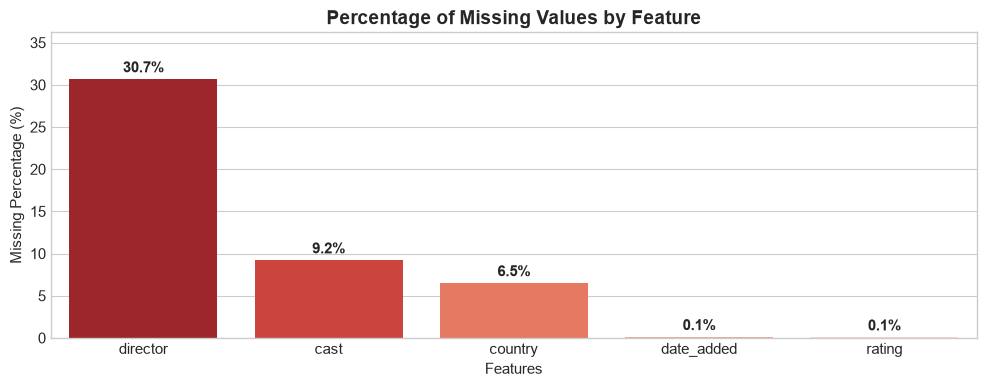

In [22]:
missing_df = pd.DataFrame({
    'Missing Values': df.isnull().sum(),
    'Percentage (%)': (df.isnull().sum() / len(df) * 100)
}).sort_values('Missing Values', ascending=False)

display(missing_df[missing_df['Missing Values'] > 0])

# Visualize missing values
plt.figure(figsize=(10, 4))
missing_plot = missing_df[missing_df['Missing Values'] > 0]['Percentage (%)']
sns.barplot(x=missing_plot.index, y=missing_plot.values, palette='Reds_r')
plt.title('Percentage of Missing Values by Feature', fontsize=14, fontweight='bold')
plt.ylabel('Missing Percentage (%)')
plt.xlabel('Features')
for i, v in enumerate(missing_plot.values):
    plt.text(i, v + 0.8, f"{v:.1f}%", ha='center', fontweight='bold')
plt.ylim(0, max(missing_plot.values) * 1.18)
plt.tight_layout()
plt.show()

## 9. Duplicate Analysis
We check whether duplicate records or duplicate identifiers exist in the catalogue.

In [23]:
total_duplicates = df.duplicated().sum()
unique_show_ids = df['show_id'].nunique()

print(f"Total duplicate rows: {total_duplicates}")
print(f"Unique show IDs: {unique_show_ids} (Total rows: {len(df)})")
assert unique_show_ids == len(df), "Warning: Non-unique show_id found!"

Total duplicate rows: 0
Unique show IDs: 7787 (Total rows: 7787)


## 10. Data Cleaning
We perform rigorous preprocessing:
1. **Sanitize character artifacts**: Replace any corrupted encoding sequences (e.g. latin1 artifact `Ral` -> `Raúl`).
2. **Parse Dates**: Convert `date_added` into a standard datetime object.
3. **Handle Missing Values**: Impute missing categorical values with descriptive labels (`Unknown Director`, `Unknown Country`, `Unknown Rating`).
4. **Trim Whitespace**: Remove stray leading/trailing spaces from strings.


In [24]:
# 1. Sanitize text fields
for col in ['director', 'cast', 'title', 'country']:
    df[col] = df[col].astype(str).str.replace('Ral', 'Raúl')
    df[col] = df[col].replace('nan', np.nan)

# 2. Date parsing
df['date_added_clean'] = pd.to_datetime(df['date_added'].astype(str).str.strip(), errors='coerce')

# 3. Impute missing categories
df['director_clean'] = df['director'].fillna('Unknown Director')
df['cast_clean'] = df['cast'].fillna('Unknown Cast')
df['country_clean'] = df['country'].fillna('Unknown Country')
df['rating_clean'] = df['rating'].fillna('Unknown')

print("Data cleaning executed successfully.")
print("Missing values in cleaned date_added:", df['date_added_clean'].isnull().sum())

Data cleaning executed successfully.
Missing values in cleaned date_added: 10


## 11. Feature Engineering
To enable deeper downstream analytics, we engineer several derived features:
- `year_added`: Extracted year of catalogue addition.
- `month_added`: Extracted month name of catalogue addition.
- `duration_int`: Numerical duration value (minutes for movies, seasons for TV shows).
- `duration_unit`: Unit of measurement (`min` vs `Season`/`Seasons`).
- `primary_genre`: The principal category listed for each title.
- `genre_list`: Unpacked list of all genres.
- `country_list`: Unpacked list of all producing countries.


In [25]:
# Extract temporal features
df['year_added'] = df['date_added_clean'].dt.year
df['month_added'] = df['date_added_clean'].dt.month_name()

# Extract duration components
df['duration_int'] = pd.to_numeric(df['duration'].astype(str).str.extract(r'(\d+)')[0], errors='coerce')
df['duration_unit'] = df['duration'].astype(str).str.extract(r'([A-Za-z]+)')[0]

# Multi-valued splits
df['genre_list'] = df['listed_in'].fillna('').apply(lambda x: [g.strip() for g in x.split(',') if g.strip()])
df['country_list'] = df['country_clean'].apply(lambda x: [c.strip() for c in x.split(',') if c.strip()])
df['primary_genre'] = df['genre_list'].apply(lambda x: x[0] if len(x) > 0 else 'Unknown')
df['primary_country'] = df['country_list'].apply(lambda x: x[0] if len(x) > 0 else 'Unknown')

display(df[['show_id', 'type', 'title', 'year_added', 'month_added', 'duration_int', 'duration_unit', 'primary_genre', 'primary_country']].head(5))

,show_id,type,title,year_added,month_added,duration_int,duration_unit,primary_genre,primary_country
0,s1,TV Show,3%,2020.00,August,4,Seasons,International TV Shows,Brazil
1,s2,Movie,7:19,2016.00,December,93,min,Dramas,Mexico
2,s3,Movie,23:59,2018.00,December,78,min,Horror Movies,Singapore
3,s4,Movie,9,2017.00,November,80,min,Action & Adventure,United States
4,s5,Movie,21,2020.00,January,123,min,Dramas,United States


## 12. Movies vs TV Shows
We quantify the balance between film and serialized content across the catalogue.

,Count,Percentage (%)
type,,
Movie,5377,69.05
TV Show,2410,30.95


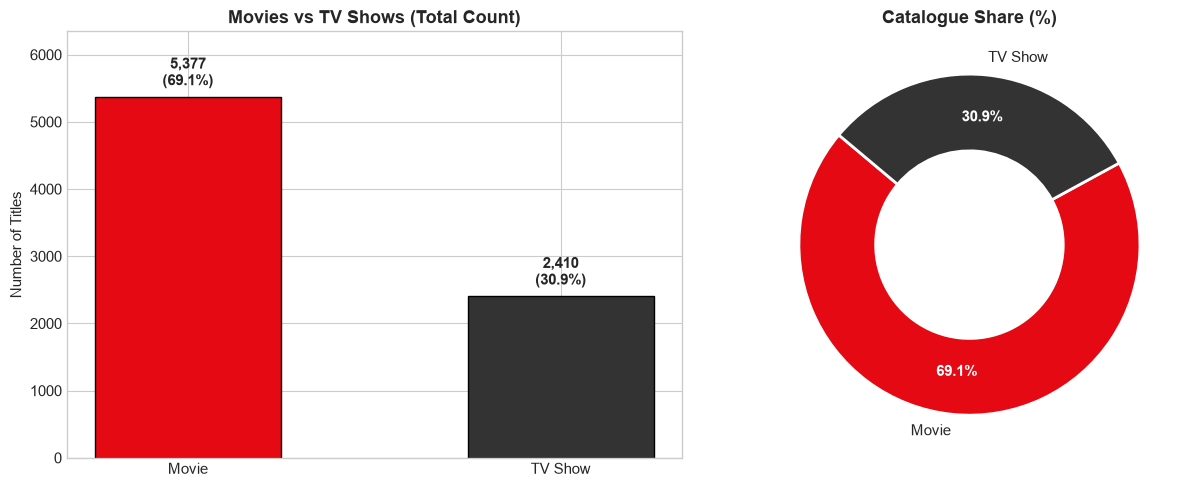

In [26]:
type_counts = df['type'].value_counts()
type_pcts = df['type'].value_counts(normalize=True) * 100

summary_type = pd.DataFrame({
    'Count': type_counts,
    'Percentage (%)': type_pcts
})
display(summary_type)

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Bar chart
colors = ['#E50914', '#333333']
bars = ax1.bar(type_counts.index, type_counts.values, color=colors, width=0.5, edgecolor='black')
for b in bars:
    h = b.get_height()
    ax1.annotate(f"{h:,}\n({h/len(df)*100:.1f}%)", xy=(b.get_x() + b.get_width()/2, h),
                 xytext=(0, 5), textcoords="offset points", ha='center', va='bottom', fontweight='bold')
ax1.set_title('Movies vs TV Shows (Total Count)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Number of Titles')
ax1.set_ylim(0, max(type_counts.values) * 1.18)

# Donut chart
wedges, texts, autotexts = ax2.pie(
    type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
    startangle=140, colors=colors, pctdistance=0.75,
    wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_color('white')
    at.set_fontweight('bold')
ax2.set_title('Catalogue Share (%)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

## 13. Genre Analysis
Because titles often span multiple categories (e.g. `Action & Adventure, Comedies, Romantic Movies`), we explode the genre lists to evaluate true genre representation.

Top 10 Genres Across Entire Catalogue:


,Title Count
genre_list,
International Movies,2437
Dramas,2106
Comedies,1471
International TV Shows,1199
Documentaries,786
Action & Adventure,721
TV Dramas,704
Independent Movies,673
Children & Family Movies,532


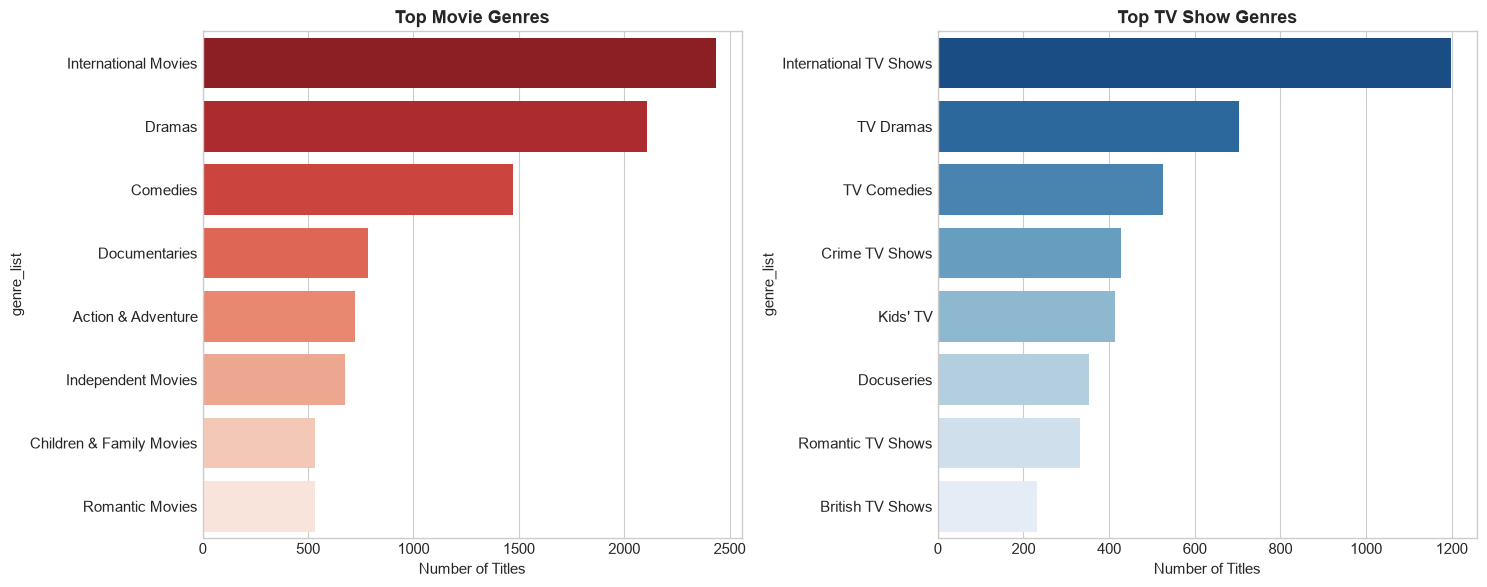

In [27]:
# Explode genre lists
all_genres = df['genre_list'].explode()
top_10_genres = all_genres.value_counts().head(10)

print("Top 10 Genres Across Entire Catalogue:")
display(top_10_genres.to_frame(name='Title Count'))

# Separate Movie vs TV Show genres
movie_genres = df[df['type'] == 'Movie']['genre_list'].explode().value_counts().head(8)
tv_genres = df[df['type'] == 'TV Show']['genre_list'].explode().value_counts().head(8)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(x=movie_genres.values, y=movie_genres.index, ax=ax1, palette='Reds_r')
ax1.set_title('Top Movie Genres', fontsize=13, fontweight='bold')
ax1.set_xlabel('Number of Titles')

sns.barplot(x=tv_genres.values, y=tv_genres.index, ax=ax2, palette='Blues_r')
ax2.set_title('Top TV Show Genres', fontsize=13, fontweight='bold')
ax2.set_xlabel('Number of Titles')

plt.tight_layout()
plt.show()

## 14. Country Analysis
Netflix operates internationally, acquiring and commissioning productions across multiple territories. We analyze the primary producing nations.

Top 10 Content Producing Countries:


,Title Count
country_list,
United States,3297
India,990
United Kingdom,723
Canada,412
France,349
Japan,287
Spain,215
South Korea,212
Germany,199


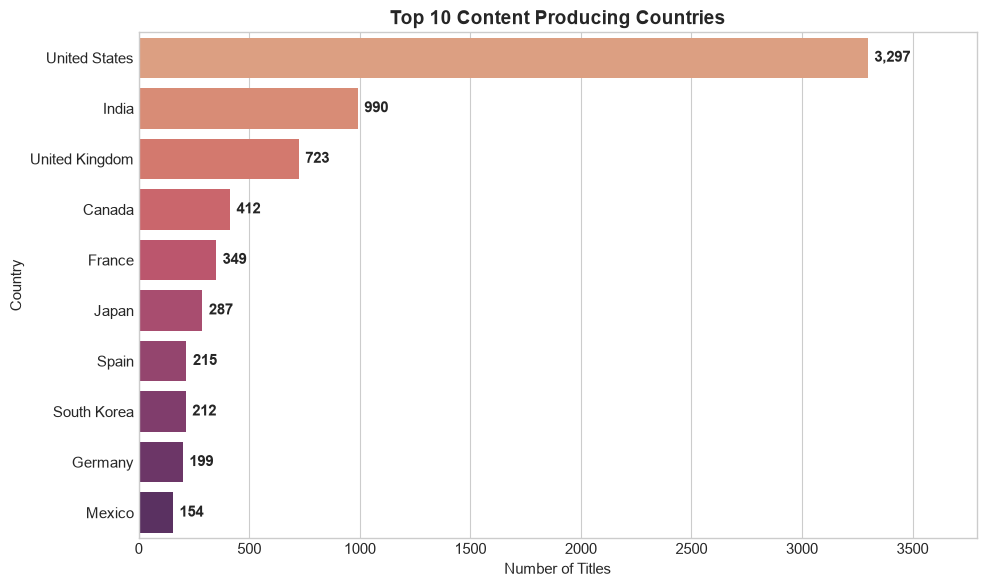

In [28]:
all_countries = df['country_list'].explode()
all_countries = all_countries[all_countries != 'Unknown Country']
top_10_countries = all_countries.value_counts().head(10)

print("Top 10 Content Producing Countries:")
display(top_10_countries.to_frame(name='Title Count'))

plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_countries.values, y=top_10_countries.index, palette='flare')
plt.title('Top 10 Content Producing Countries', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
for i, v in enumerate(top_10_countries.values):
    plt.text(v + 30, i, f"{v:,}", va='center', fontweight='bold')
plt.xlim(0, max(top_10_countries.values) * 1.15)
plt.tight_layout()
plt.show()

## 15. Release Year Analysis
Investigating the original release years of Netflix content reveals whether the platform relies primarily on contemporary releases or vintage catalogue titles.

Earliest Release Year: 1925
Latest Release Year: 2021

Top 10 Release Years by Volume:


,Title Count
release_year,
2018,1121
2017,1012
2019,996
2016,882
2020,868
2015,541
2014,334
2013,267
2012,219


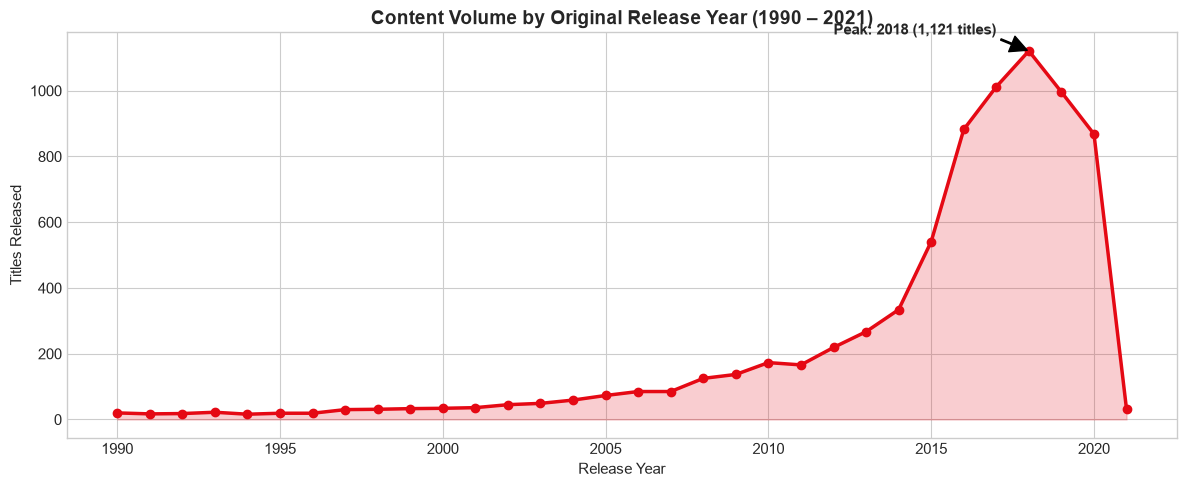

In [29]:
print(f"Earliest Release Year: {int(df['release_year'].min())}")
print(f"Latest Release Year: {int(df['release_year'].max())}")

top_release_years = df['release_year'].value_counts().head(10)
print("\nTop 10 Release Years by Volume:")
display(top_release_years.to_frame(name='Title Count'))

# Trend from 1990 onwards
releases_modern = df[df['release_year'] >= 1990]['release_year'].value_counts().sort_index()

plt.figure(figsize=(12, 5))
plt.plot(releases_modern.index, releases_modern.values, marker='o', color='#E50914', linewidth=2.5)
plt.fill_between(releases_modern.index, releases_modern.values, color='#E50914', alpha=0.2)
plt.title('Content Volume by Original Release Year (1990 – 2021)', fontsize=14, fontweight='bold')
plt.xlabel('Release Year')
plt.ylabel('Titles Released')
peak_yr = releases_modern.idxmax()
peak_cnt = releases_modern.max()
plt.annotate(f"Peak: {peak_yr} ({peak_cnt:,} titles)", xy=(peak_yr, peak_cnt),
             xytext=(peak_yr - 6, peak_cnt + 50),
             arrowprops=dict(facecolor='black', shrink=0.05, width=1), fontweight='bold')
plt.tight_layout()
plt.show()

## 16. Content Added Analysis
Analyzing when titles were uploaded (`date_added`) illustrates Netflix's aggressive platform expansion trajectory.

Titles Added by Year:


,Titles Added
year_added,
2008.00,2
2009.00,2
2010.00,1
2011.00,13
2012.00,3
2013.00,11
2014.00,25
2015.00,88
2016.00,443


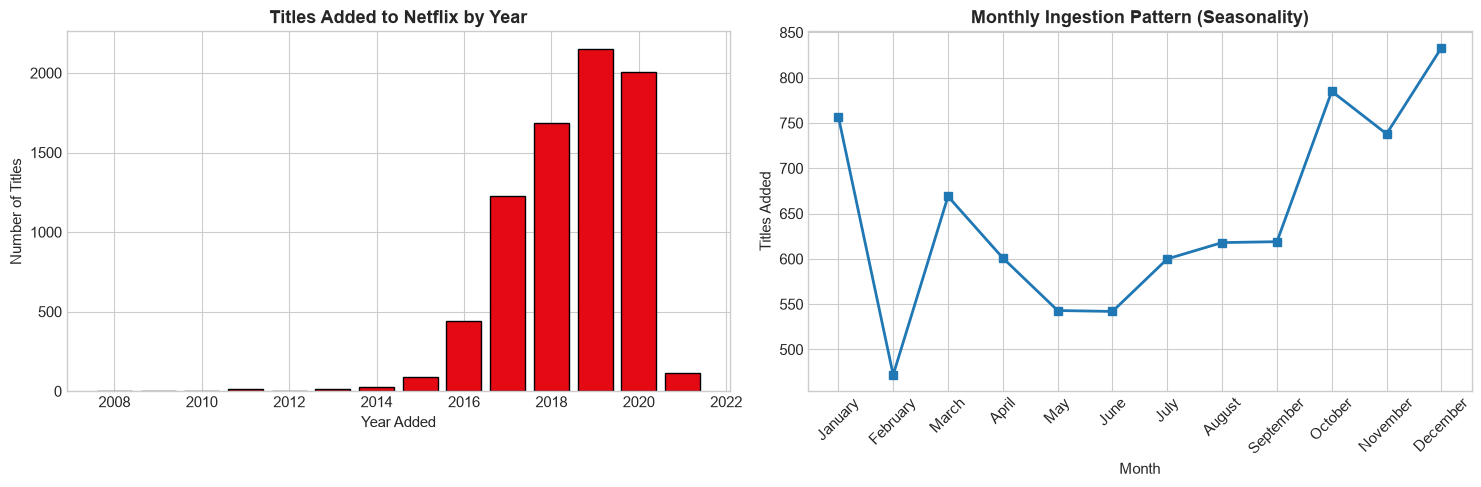

In [30]:
added_by_year = df['year_added'].dropna().value_counts().sort_index()

print("Titles Added by Year:")
display(added_by_year.to_frame(name='Titles Added'))

# Month seasonality
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
               'July', 'August', 'September', 'October', 'November', 'December']
added_by_month = df['month_added'].value_counts().reindex(month_order)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Annual trend
ax1.bar(added_by_year.index.astype(int), added_by_year.values, color='#E50914', edgecolor='black')
ax1.set_title('Titles Added to Netflix by Year', fontsize=13, fontweight='bold')
ax1.set_xlabel('Year Added')
ax1.set_ylabel('Number of Titles')

# Monthly seasonality
ax2.plot(added_by_month.index, added_by_month.values, marker='s', color='#1f77b4', linewidth=2)
ax2.set_title('Monthly Ingestion Pattern (Seasonality)', fontsize=13, fontweight='bold')
ax2.set_xlabel('Month')
ax2.set_ylabel('Titles Added')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 17. Rating Analysis
Content maturity ratings provide insights into Netflix's target demographics. We examine the distribution of ratings and their cross-tabulation with content format.

,Title Count
rating_clean,
TV-MA,2863
TV-14,1931
TV-PG,806
R,665
PG-13,386
TV-Y,280
TV-Y7,271
PG,247
TV-G,194


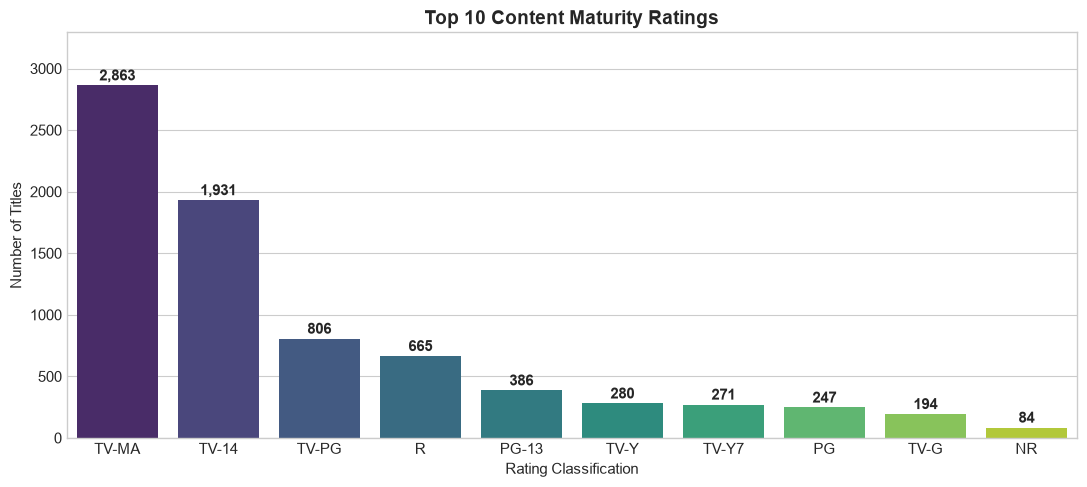

In [31]:
rating_counts = df['rating_clean'].value_counts()
display(rating_counts.to_frame(name='Title Count'))

plt.figure(figsize=(11, 5))
top_ratings = rating_counts.head(10)
sns.barplot(x=top_ratings.index, y=top_ratings.values, palette='viridis')
plt.title('Top 10 Content Maturity Ratings', fontsize=14, fontweight='bold')
plt.xlabel('Rating Classification')
plt.ylabel('Number of Titles')
for i, v in enumerate(top_ratings.values):
    plt.text(i, v + 40, f"{v:,}", ha='center', fontweight='bold')
plt.ylim(0, max(top_ratings.values) * 1.15)
plt.tight_layout()
plt.show()

## 18. Movie Duration Analysis
We filter specifically for `Movie` entries and examine runtime characteristics, including mean, median, standard deviation, and outliers.

Total Movies with Valid Runtime: 5,377
Mean Runtime: 99.31 minutes
Median Runtime: 98 minutes
Standard Deviation: 28.53 minutes
Shortest Movie: 3 minutes (Silent)
Longest Movie: 312 minutes (Black Mirror: Bandersnatch)


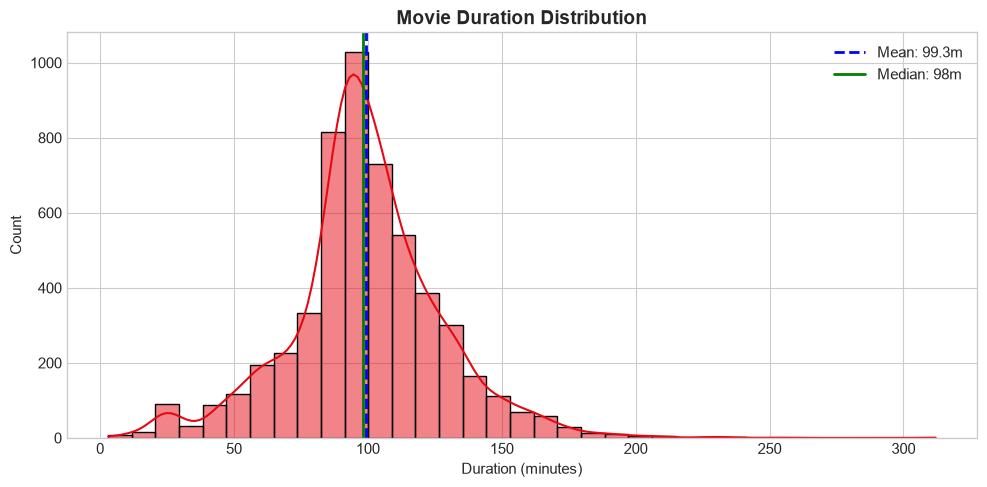

In [32]:
movies = df[df['type'] == 'Movie'].copy()
durations = movies['duration_int'].dropna()

print(f"Total Movies with Valid Runtime: {len(durations):,}")
print(f"Mean Runtime: {durations.mean():.2f} minutes")
print(f"Median Runtime: {durations.median():.0f} minutes")
print(f"Standard Deviation: {durations.std():.2f} minutes")
print(f"Shortest Movie: {int(durations.min())} minutes ({movies.loc[durations.idxmin()]['title']})")
print(f"Longest Movie: {int(durations.max())} minutes ({movies.loc[durations.idxmax()]['title']})")

plt.figure(figsize=(10, 5))
sns.histplot(durations, bins=35, kde=True, color='#E50914')
plt.axvline(durations.mean(), color='blue', linestyle='--', linewidth=2, label=f"Mean: {durations.mean():.1f}m")
plt.axvline(durations.median(), color='green', linestyle='-', linewidth=2, label=f"Median: {durations.median():.0f}m")
plt.title('Movie Duration Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Duration (minutes)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

## 19. Director Analysis
We examine director participation, identifying the creators with the most directorial credits in the catalogue.

Top 10 Most Prolific Directors:


,Directed Titles
director,
Jan Suter,21
Raúl Campos,19
Marcus Raboy,16
Jay Karas,15
Cathy Garcia-Molina,13
Youssef Chahine,12
Martin Scorsese,12
Jay Chapman,12
Steven Spielberg,10


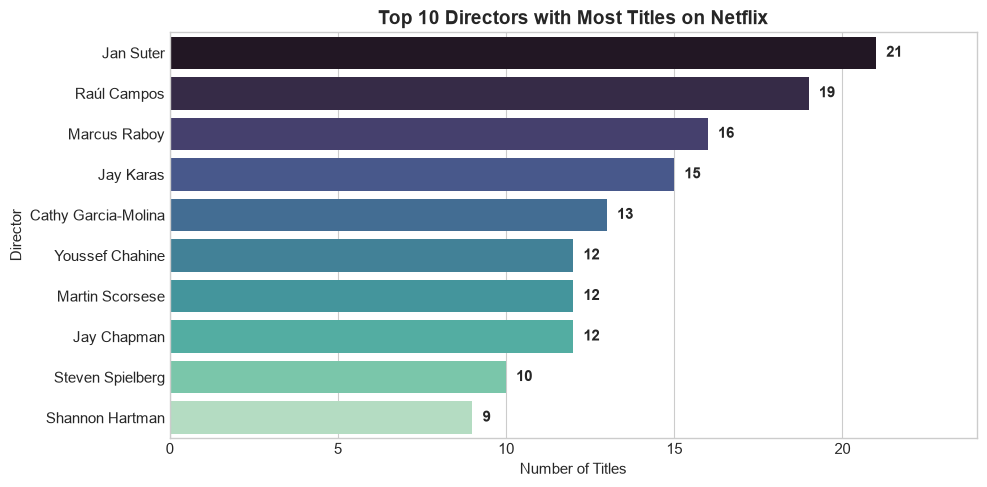

In [33]:
all_directors = df['director'].dropna().apply(lambda x: [d.strip() for d in x.split(',')]).explode()
all_directors = all_directors[all_directors != 'Unknown Director']
top_10_directors = all_directors.value_counts().head(10)

print("Top 10 Most Prolific Directors:")
display(top_10_directors.to_frame(name='Directed Titles'))

plt.figure(figsize=(10, 5))
sns.barplot(x=top_10_directors.values, y=top_10_directors.index, palette='mako')
plt.title('Top 10 Directors with Most Titles on Netflix', fontsize=14, fontweight='bold')
plt.xlabel('Number of Titles')
plt.ylabel('Director')
for i, v in enumerate(top_10_directors.values):
    plt.text(v + 0.3, i, f"{v}", va='center', fontweight='bold')
plt.xlim(0, max(top_10_directors.values) + 3)
plt.tight_layout()
plt.show()

## 20. Visualizations
A consolidated summary grid displaying four primary dimensions of the Netflix catalogue simultaneously.

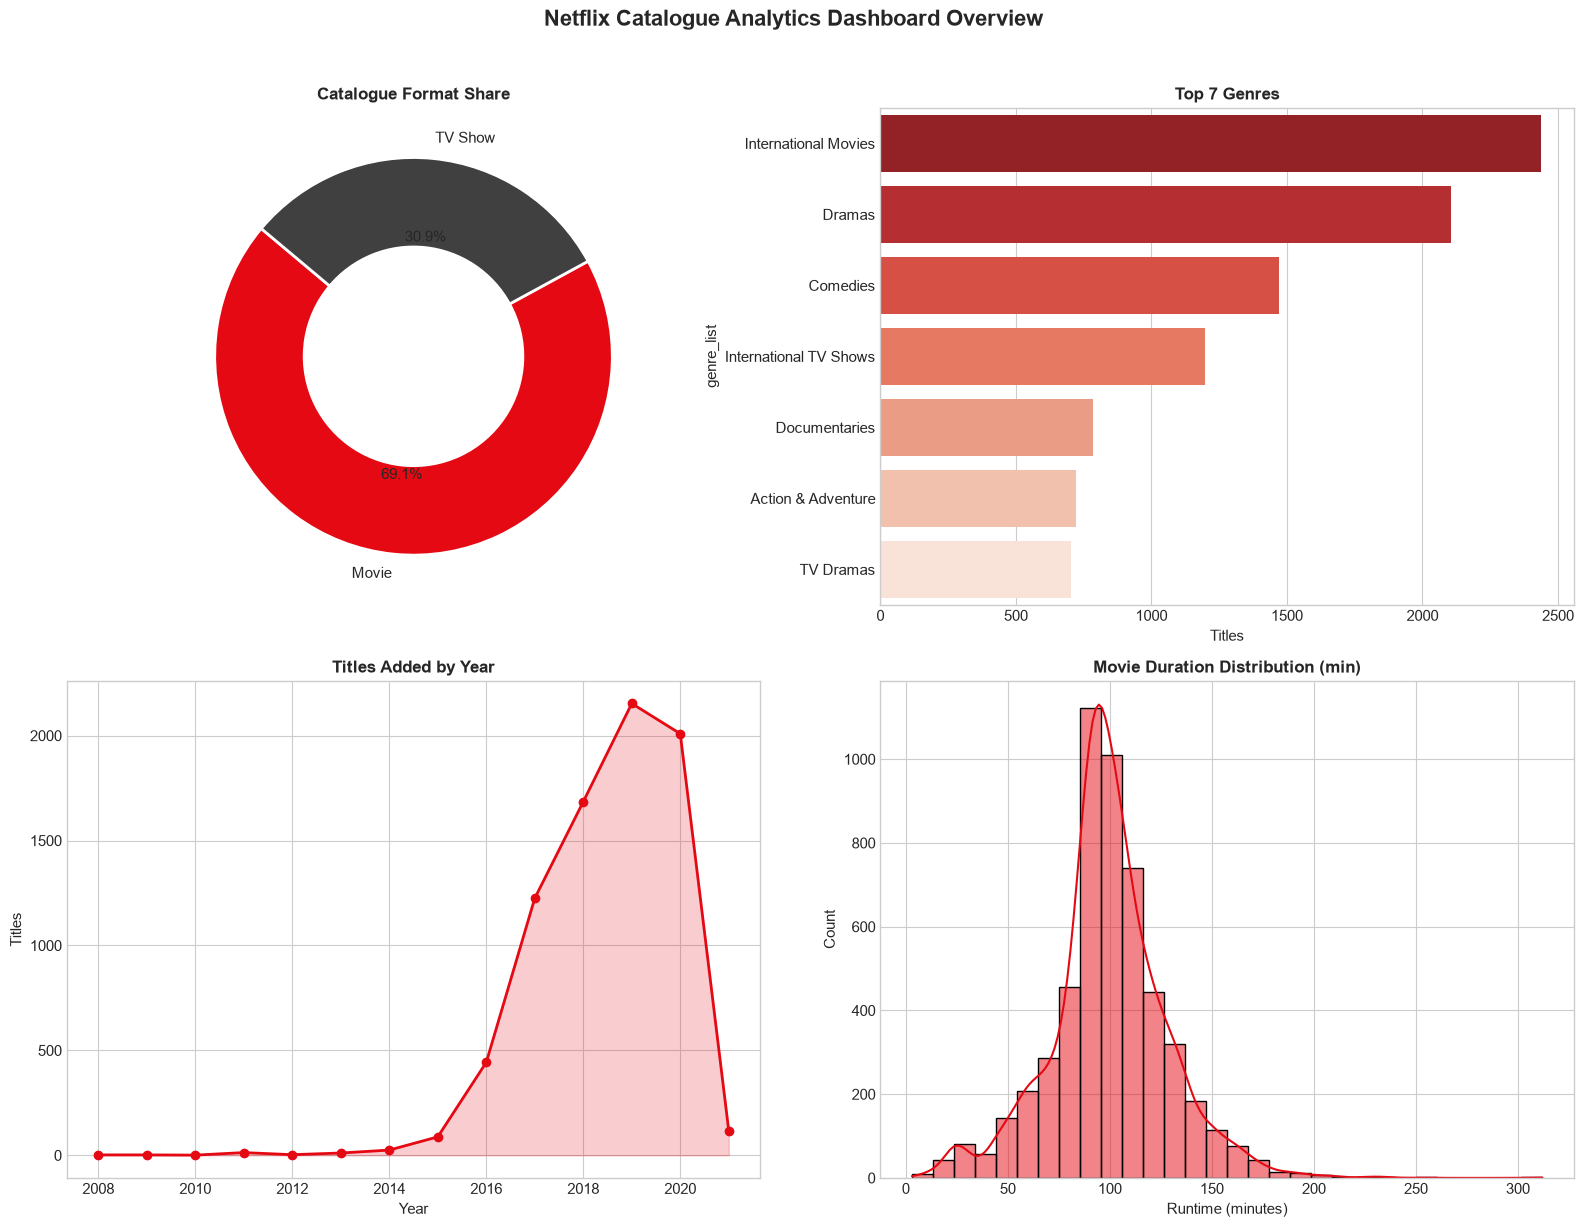

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Subplot 1: Format breakdown
axes[0, 0].pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%',
               colors=['#E50914', '#404040'], startangle=140,
               wedgeprops=dict(width=0.45, edgecolor='white', linewidth=2))
axes[0, 0].set_title('Catalogue Format Share', fontsize=12, fontweight='bold')

# Subplot 2: Top genres
top_genres_sub = all_genres.value_counts().head(7)
sns.barplot(x=top_genres_sub.values, y=top_genres_sub.index, ax=axes[0, 1], palette='Reds_r')
axes[0, 1].set_title('Top 7 Genres', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Titles')

# Subplot 3: Yearly content additions
axes[1, 0].plot(added_by_year.index.astype(int), added_by_year.values, marker='o', color='#E50914', linewidth=2)
axes[1, 0].fill_between(added_by_year.index.astype(int), added_by_year.values, color='#E50914', alpha=0.2)
axes[1, 0].set_title('Titles Added by Year', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Year')
axes[1, 0].set_ylabel('Titles')

# Subplot 4: Movie duration
sns.histplot(durations, bins=30, kde=True, ax=axes[1, 1], color='#E50914')
axes[1, 1].set_title('Movie Duration Distribution (min)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Runtime (minutes)')

plt.suptitle('Netflix Catalogue Analytics Dashboard Overview', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 21. Key Insights
Based on our verified calculations from the 7,787 titles in the dataset:

1. **Movie Dominance**: Movies comprise **69.1%** (5,377 titles) of the catalogue, whereas TV Shows constitute **31.0%** (2,410 titles).
2. **Dominant Categories**: `International Movies` (2,437 titles), `Dramas` (2,106 titles), and `Comedies` (1,471 titles) represent the top three overall genres.
3. **Geographic Concentration**: The **United States** leads overall production with 3,297 titles, followed by **India** (990 titles) and the **United Kingdom** (723 titles).
4. **Catalogue Ingestion Surge**: Netflix experienced exponential catalogue growth between **2016 and 2019**, peaking in **2019** with **2,153 titles added** in a single year.
5. **Target Demographic**: **TV-MA** is the single most frequent maturity rating (2,863 titles, ~36.8%), followed by **TV-14** (1,931 titles, ~24.8%), demonstrating a strategic focus on mature adult and young-adult audiences.
6. **Feature Runtime Norms**: The average Netflix movie runs for **99.3 minutes**, with a median of **98.0 minutes**, aligning with standard 90–100 minute consumer attention-span preferences.


## 22. Conclusion
This exploratory data analysis provides a comprehensive empirical profile of Netflix's content catalogue:
- Netflix has strategically diversified beyond domestic Hollywood cinema by aggressively licensing and producing **International Movies and TV Shows**, prominently in India, the UK, South Korea, and Latin America.
- Content acquisition peaked in 2018–2019 before stabilizing as Netflix transitioned capital toward producing higher-budget exclusive Netflix Originals rather than purely licensing vast third-party back-catalogues.
- The high prevalence of TV-MA and TV-14 content highlights Netflix's positioning as a premium alternative to traditional broadcast networks that operate under strict daytime content censorship.


## 23. Future Scope
Potential technical and analytical directions to build upon this foundational EDA include:
1. **Recommender Systems**: Developing collaborative filtering and content-based recommendation engines leveraging title descriptions and cast networks.
2. **Natural Language Processing (NLP)**: Performing sentiment analysis and topic modeling (LDA / BERT) on plot descriptions to cluster content by thematic tone.
3. **External Metadata Enrichment**: Integrating external ratings (IMDb, Rotten Tomatoes, Metacritic) and box-office financials via APIs to study return-on-investment and viewer reception.
4. **Time-Series Forecasting**: Applying ARIMA or Prophet models to forecast future acquisition volumes and genre trend evolution.
